In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['Microsoft YaHei']
import seaborn as sns

In [3]:
# 导入数据
df_1 = sns.load_dataset("titanic")
df_1

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,1,2,female,28.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True
636,0,3,male,32.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
637,0,2,male,31.0,1,1,26.2500,S,Second,man,True,NaN,Southampton,no,False
638,0,3,female,41.0,0,5,39.6875,S,Third,woman,False,NaN,Southampton,no,False


In [4]:
# 数据基本信息了解
df_1.describe()
df_1.info()
df_1.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     640 non-null    int64   
 1   pclass       640 non-null    int64   
 2   sex          640 non-null    object  
 3   age          506 non-null    float64 
 4   sibsp        640 non-null    int64   
 5   parch        640 non-null    int64   
 6   fare         640 non-null    float64 
 7   embarked     639 non-null    object  
 8   class        639 non-null    category
 9   who          639 non-null    object  
 10  adult_male   639 non-null    object  
 11  deck         143 non-null    category
 12  embark_town  638 non-null    object  
 13  alive        639 non-null    object  
 14  alone        639 non-null    object  
dtypes: category(2), float64(2), int64(4), object(7)
memory usage: 66.9+ KB


survived         0
pclass           0
sex              0
age            134
sibsp            0
parch            0
fare             0
embarked         1
class            1
who              1
adult_male       1
deck           497
embark_town      2
alive            1
alone            1
dtype: int64

In [5]:
# 不难发现，有一些列的含义完全相同，因此可以保留更简单的一列
df_1.drop(columns=['class','embark_town','alive'],inplace=True)    # inplace参数是什么意思？


In [6]:
print(df_1.isna().sum())
df_1

survived        0
pclass          0
sex             0
age           134
sibsp           0
parch           0
fare            0
embarked        1
who             1
adult_male      1
deck          497
alone           1
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...
635,1,2,female,28.0,0,0,13.0000,S,woman,False,NaN,True
636,0,3,male,32.0,0,0,7.9250,S,man,True,NaN,True
637,0,2,male,31.0,1,1,26.2500,S,man,True,NaN,False
638,0,3,female,41.0,0,5,39.6875,S,woman,False,NaN,False


In [7]:
# 对缺失值进行处理，其中主要是age和deck
# age缺失值的处理，应该先按照pclass和sex进行分组求中位数，然后再对应填入。对于deck，缺失过多，直接删掉
df_1 = df_1.fillna({
    'age':df_1.groupby(['pclass','sex'],observed=True)['age'].transform('median')
})
#df_1 = df_1.drop(columns=['deck'])
# 由于其他几列缺失值极少，因此直接剔除掉
df_1 = df_1.dropna(subset=['embarked','who','adult_male','alone'])
df_1


# 然后对一些type进行转换
bool_cols = ['adult_male','alone']
for col in bool_cols:
    df_1[col] = df_1[col].astype('bool')

cat_cols = ['sex','embarked','who']
for col in cat_cols:
    df_1[col] = df_1[col].astype('category')
df_1

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...
634,0,3,female,9.0,3,2,27.9000,S,child,False,NaN,False
635,1,2,female,28.0,0,0,13.0000,S,woman,False,NaN,True
636,0,3,male,32.0,0,0,7.9250,S,man,True,NaN,True
637,0,2,male,31.0,1,1,26.2500,S,man,True,NaN,False


## 单因素分析

In [8]:
# 1.求整体幸存率
print('乘客的整体幸存率为：',df_1['survived'].mean())


乘客的整体幸存率为： 0.390282131661442


不同性别的乘客的幸存率分别为： sex
female    0.743590
male      0.185644
Name: survived, dtype: float64


Text(0.5, 1.0, '男性和女性乘客的幸存率')

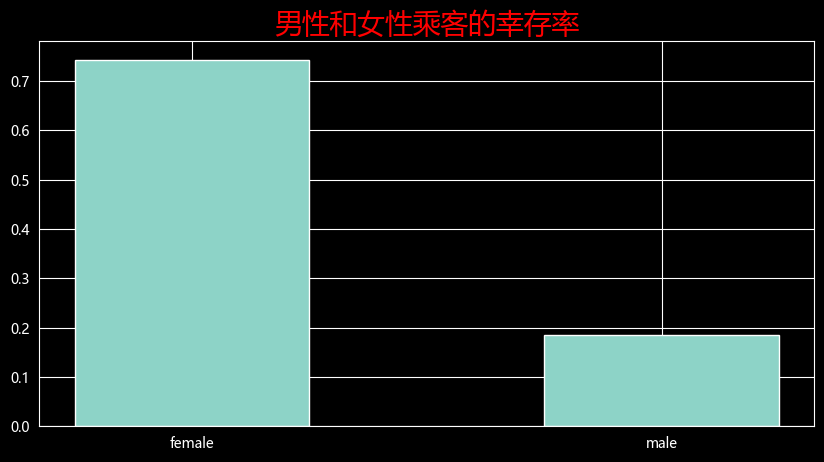

In [9]:
# 2.性别对幸存率的影响
group_gender = df_1.groupby('sex',observed=True)['survived']
print('不同性别的乘客的幸存率分别为：',group_gender.mean())
plt.figure(figsize=(10,5))
x = group_gender.mean().index
y = group_gender.mean().values
plt.bar(x,y,
        label='Score',
        width=0.5)
plt.title('男性和女性乘客的幸存率',fontsize=20,color='red')

([<matplotlib.axis.XTick at 0x1b2e7e38730>,
 [Text(1, 0, '1st class'), Text(2, 0, '2nd class'), Text(3, 0, '3rd class')])

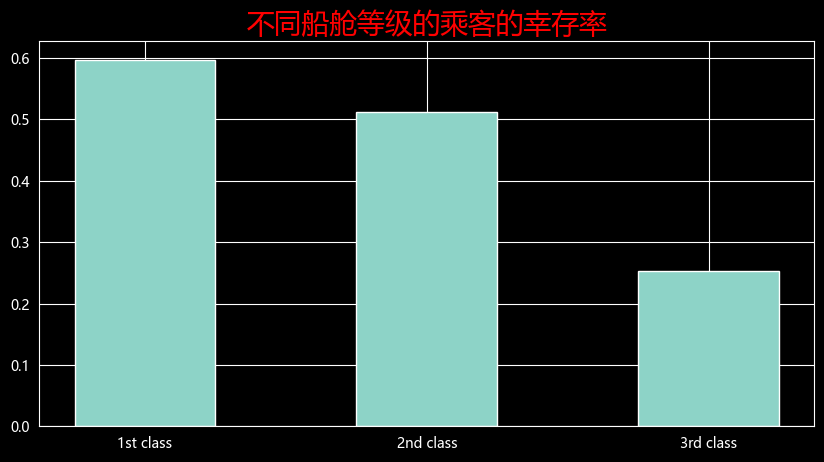

In [10]:
# 船舱等级对于幸存率的影响
group_class = df_1.groupby('pclass',observed=True)['survived']
plt.figure(figsize=(10,5))
x2 = group_class.mean().index
y2 = group_class.mean().values
plt.bar(x2,y2,
        label='Score',
        width=0.5)
plt.title('不同船舱等级的乘客的幸存率',fontsize=20,color='red')
# 这个表虽然可以看得懂，但是不好看，尤其是横刻度，是直接按照数字格式输出的
plt.xticks([1,2,3], ['1st class','2nd class','3rd class'])

## 双因素分析

若参照性别和船舱等级两个指标来分组，乘客的幸存率分别为：
 pclass         1         2         3
sex                                 
female  0.954545  0.932203  0.513761
male    0.329545  0.175676  0.136364


([<matplotlib.axis.XTick at 0x1b2ea2d2500>,
 [Text(1, 0, '1st class'), Text(2, 0, '2nd class'), Text(3, 0, '3rd class')])

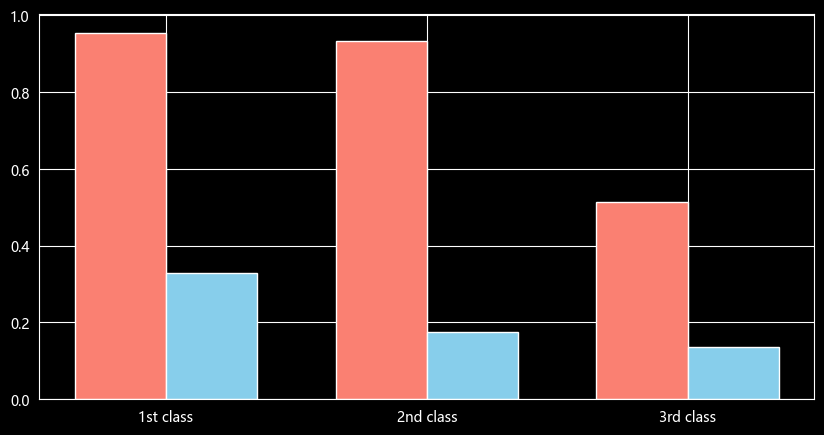

In [11]:
group_cla_gen = df_1.groupby(['sex','pclass'],observed = True)['survived']
print('若参照性别和船舱等级两个指标来分组，乘客的幸存率分别为：\n',group_cla_gen.mean().unstack())
plt.figure(figsize=(10,5))
# 获取 x 轴位置（这里用 pclass 的取值）
x = group_cla_gen.mean().unstack().columns
width = 0.35  #

# 画女性柱子
plt.bar(x - width/2, group_cla_gen.mean().unstack().loc['female'], width, label='Female', color='salmon')

# 画男性柱子
plt.bar(x + width/2, group_cla_gen.mean().unstack().loc['male'], width, label='Male', color='skyblue')

plt.xticks([1,2,3],['1st class','2nd class','3rd class'])

幸存者与遇难者的平均年龄分别为：
 survived
0    30.215938
1    28.208835
Name: age, dtype: float64


<Axes: xlabel='survived', ylabel='age'>

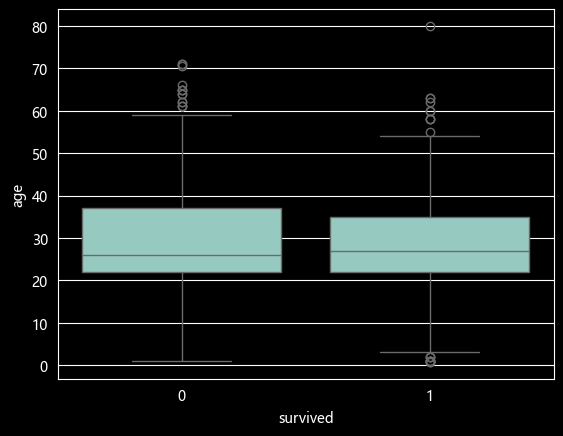

In [12]:
group_age = df_1.groupby('survived')['age']
print('幸存者与遇难者的平均年龄分别为：\n',group_age.mean())
sns.boxplot(x='survived', y='age', data=df_1)


In [13]:
# 男性女性和儿童分别的获救情况
group_who = df_1.groupby('who',observed = False)['survived']
print('不同身份获救的概率：',group_who.mean())

不同身份获救的概率： who
child    0.571429
man      0.163588
woman    0.763547
Name: survived, dtype: float64


In [14]:
df_1.groupby(['who','alone'], observed = False)['survived'].mean()


who    alone
child  False    0.574074
       True     0.500000
man    False    0.166667
       True     0.162544
woman  False    0.741071
       True     0.791209
Name: survived, dtype: float64

In [15]:
df_1.groupby('embarked')['survived'].mean()


C:\Users\15548\AppData\Local\Temp\ipykernel_12864\1128577231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_1.groupby('embarked')['survived'].mean()


embarked
C    0.532787
Q    0.448276
S    0.344978
Name: survived, dtype: float64